### **PROJET- EDS CAMEROUN**: SANTE MATERNELLE DES FEMMES MARIEES AU CAMEROUN

### **PARTIE A**:   ANALYSE STATISTIQUES SUR LA SANTE MATERNELLE PRECISEMENT SUR L'ACCOUCHEMENT AVEC OU SANS ASSISTANCE D'UN PERSONEL QUALIFIE 

In [1]:
# importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# importation du dataset
dataIR=pd.read_csv("CMIR71FL.csv")

In [3]:
# affichage des premières lignes du dataset 
dataIR.head()

,CASEID,V000,V001,V002,V003,V004,V005,V006,V007,V008,...,S234$3,S234$4,S234$5,S234$6,S233C$1,S233C$2,S233C$3,S233C$4,S233C$5,S233C$6
0,1 125 2,CM7,1,125,2,1,990064,7,2018,1423,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1 125 3,CM7,1,125,3,1,990064,7,2018,1423,...,NaN,NaN,NaN,NaN,1359.0,NaN,NaN,NaN,NaN,NaN
2,1 147 2,CM7,1,147,2,1,990064,7,2018,1423,...,NaN,NaN,NaN,NaN,1367.0,NaN,NaN,NaN,NaN,NaN
3,1 147 3,CM7,1,147,3,1,990064,7,2018,1423,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1 191 2,CM7,1,191,2,1,990064,7,2018,1423,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


###
Nettoyage des donnees

###
Liste des variables :

* Identification et Pondération:
   - CASIED
   - V005
   - V021 
   - V023
* Variable Dépendante (Santé Maternelle):
   - M3A$1: Docteur
   - M3B$1: Infirmière / Sage-femme 
   
* Variables independantes 
   * caracteristique de la femme:
      - v012: age actuel de la femme
      - v013:  Âge en groupes
      - v024:  Région 
      - V025:  Milieu de résidence (Urbain/Rural)
      - V106:  Niveau d'éducation
      - V130:  Religion
      - V190:  Indice de richesse (Wealth index)
      - V201:  Parité (Nombre total d'enfants nés)
      - V501:  Statut matrimonial (pour le filtrage) 
      - M2A$1 : Soins prénatals prodigués par du personnel qualifié ( medecin)
      - M2B$1 : Soins prénatals prodigués par du personnel qualifié ( infimiere/sage femme)
   * Caractéristiques du Mari:
      - V701: Niveau d'éducation du mari
   * Exposition aux Médias
      - V157: Lecture de journaux
      - V158: Écoute de la radio
      - V159: Visionnage de la télévision
   * Autonomie Décisionnelle
      - V743A: Décision : Personne qui décide habituellement des soins de santé du répondant
      - V743B: Décision : La personne qui décide généralement des gros achats ménagers  
      - V743D: Décision : La personne qui décide habituellement des visites à la famille ou aux proches
   * Violence conjugale 
      - V744A: Les coups sont justifiés si la femme sort sans prévenir son mari
      - V744B: Les coups sont justifiés si la femme néglige les enfants
      - V744C: Les coups sont justifiés si la femme se dispute avec son mari
      - V744D: Les coups sont justifiés si la femme refuse d'avoir des relations sexuelles avec son mari
      - V744E: Les coups sont justifiés si la femme brûle le repas


In [4]:
#selection des variables d'intérêt
variables_interet = ["CASEID", "V005", "V021","V023",
                    "M3A$1","M3B$1","M3C$1",
                     "V012", "V013","V024", "V025","V106", "V130", "V190","V201","V501","M2A$1","M2B$1","V701",
                     "V157","V158","V159", "V743A", "V743B","V743D","V744A","V744B","V744C","V744D","V744E"
                     ]

# creation du nouveau dataframe avec les variables d'intérêt    
dataIR_selected = dataIR[variables_interet]

In [5]:
# affichage des premières lignes du dataset sélectionné
dataIR_selected.head()

,CASEID,V005,V021,V023,M3A$1,M3B$1,M3C$1,V012,V013,V024,...,V158,V159,V743A,V743B,V743D,V744A,V744B,V744C,V744D,V744E
0,1 125 2,990064,1,8,0.0,1.0,0.0,31,4,5,...,0,0,2.0,2.0,2.0,0,0,0,0,0
1,1 125 3,990064,1,8,0.0,0.0,0.0,19,1,5,...,0,0,NaN,NaN,NaN,0,0,0,0,0
2,1 147 2,990064,1,8,0.0,1.0,0.0,22,2,5,...,2,2,1.0,1.0,1.0,0,1,0,0,0
3,1 147 3,990064,1,8,NaN,NaN,NaN,16,1,5,...,0,0,NaN,NaN,NaN,0,0,0,0,0
4,1 191 2,990064,1,8,NaN,NaN,NaN,17,1,5,...,0,0,4.0,4.0,4.0,0,0,0,0,0


In [6]:
dataIR_selected.shape

(14677, 30)

In [7]:
dataIR_selected=dataIR_selected[dataIR_selected["M3A$1"].notna()]

In [8]:
# filtrage des femmes mariees
dataIR_married = dataIR_selected[(dataIR_selected["V501"] == 1) | (dataIR_selected["V501"] == 2)]

In [9]:
dataIR_married.shape

(5013, 30)

In [10]:
# filtrage des ages des femmes mariees de 15 a 49 ans
dataIR_married_age = dataIR_married[(dataIR_married["V012"] >= 15) & (dataIR_married["V012"] <= 49)]

In [11]:
# taille du nouveau dataset après filtrage
dataIR_married_age.shape

(5013, 30)

In [12]:
# contruction de la variable dependante SBA
# Recréation propre et sécurisée de la condition SBA avec gestion des NaN
condition_SBA = (
    (dataIR_married_age["M3A$1"].fillna(0) == 1) | 
    (dataIR_married_age["M3B$1"].fillna(0) == 1) | 
    (dataIR_married_age["M3C$1"].fillna(0) == 1)
)

dataIR_married_age["SBA"] = np.where(condition_SBA, 1, 0)

In [13]:
# construction de la variable  ANC
dataIR_married_age["ANC"] = np.where((dataIR_married_age["M2A$1"] == 1) | (dataIR_married_age["M2B$1"] == 1), 1, 0) 

In [14]:
# creation de la variable d'exposition au media
# verification de la condition
conditions_media = [
    (dataIR_married_age["V157"] >= 1) | (dataIR_married_age["V158"] >= 1) | (dataIR_married_age["V159"] >= 1)
    ]
# creation de la variable
dataIR_married_age["Media_exposure"] = np.where(conditions_media[0], 1, 0)

###
creation de la variable de l'autonomie decisionnelle de la femme

In [15]:
# créeation des variables binaires (1 si elle participe, 0 sinon) pour chaque décision
dec_sante = dataIR_married_age['V743A'].isin([1, 2]).astype(int)
dec_achats = dataIR_married_age['V743B'].isin([1, 2]).astype(int)
dec_visites = dataIR_married_age['V743D'].isin([1, 2]).astype(int)

# somme pour avoir un score de 0 à 3
dataIR_married_age['nb_decisions'] = dec_sante + dec_achats + dec_visites

#  créeation des 3 catégories 
#  utilisation des chiffres (1, 2, 3) pour que les modèles de Machine Learning comprennent
conditions = [
    (dataIR_married_age['nb_decisions'] == 0),
    (dataIR_married_age['nb_decisions'].isin([1, 2])),
    (dataIR_married_age['nb_decisions'] == 3)
]

# 1:Basse, 2:Moyenne, 3:Haute
choix = [1, 2, 3] 

dataIR_married_age['autonomie_decisionnelle'] = np.select(conditions, choix, default=np.nan)

In [16]:
# creation d'une condition 
condition_violence = (
    (dataIR_married_age['V744A'] == 1) | 
    (dataIR_married_age['V744B'] == 1) | 
    (dataIR_married_age['V744C'] == 1) | 
    (dataIR_married_age['V744D'] == 1) | 
    (dataIR_married_age['V744E'] == 1)
)

# application : 1 si elle justifie, 0 sinon 
dataIR_married_age['attitude_violence'] = np.where(condition_violence, 1, 0)

In [17]:
# data finale pour les analyses
variables_finales = ["CASEID", "V005", "V021","V023",
                     "V013","V024", "V025","V106", "V130", "V190","V201", "V701",
                    "SBA", "ANC", "Media_exposure", "autonomie_decisionnelle", "attitude_violence"
                    ]
# dataframe final
dataIR_final = dataIR_married_age[variables_finales]

In [18]:
# affichage des premières lignes du dataset sélectionné
dataIR_final.head()

,CASEID,V005,V021,V023,V013,V024,V025,V106,V130,V190,V201,V701,SBA,ANC,Media_exposure,autonomie_decisionnelle,attitude_violence
0,1 125 2,990064,1,8,4,5,1,2,1,2,4,0.0,1,1,0,3.0,0
2,1 147 2,990064,1,8,2,5,1,2,4,4,1,2.0,1,1,1,3.0,1
5,1 191 3,990064,1,8,2,5,1,1,4,3,1,0.0,1,1,0,1.0,0
6,1 198 1,990064,1,8,3,5,1,1,2,3,4,2.0,0,1,1,2.0,1
7,1 252 2,990064,1,8,5,5,1,0,4,3,8,2.0,0,1,0,2.0,0


In [19]:
dataIR_final.shape

(5013, 17)

In [20]:
# type de donnees
dataIR_final.dtypes

CASEID                      object
V005                         int64
V021                         int64
V023                         int64
V013                         int64
V024                         int64
V025                         int64
V106                         int64
V130                         int64
V190                         int64
V201                         int64
V701                       float64
SBA                          int64
ANC                          int64
Media_exposure               int64
autonomie_decisionnelle    float64
attitude_violence            int64
dtype: object

In [21]:
# conversion de certaines variables en categorie
# Liste des variables qui sont en réalité des catégories
variables_catégorielles = [
    'V013', 'V024', 'V025', 'V106', 'V130', 'V190', 'V701', 
    'SBA', 'ANC', 'Media_exposure', 'autonomie_decisionnelle', 'attitude_violence'
]

# Boucle pour convertir chaque colonne en type 'category'
for col in variables_catégorielles:
    dataIR_final[col] = dataIR_final[col].astype('category')

# Vérification du nouveau dtypes
print(dataIR_final.dtypes)

CASEID                       object
V005                          int64
V021                          int64
V023                          int64
V013                       category
V024                       category
V025                       category
V106                       category
V130                       category
V190                       category
V201                          int64
V701                       category
SBA                        category
ANC                        category
Media_exposure             category
autonomie_decisionnelle    category
attitude_violence          category
dtype: object


C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_11068\1509700171.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataIR_final[col] = dataIR_final[col].astype('category')
C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_11068\1509700171.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataIR_final[col] = dataIR_final[col].astype('category')
C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_11068\1509700171.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFr

In [22]:
# detection des valeurs manquantes
dataIR_final.isna().sum()

CASEID                     0
V005                       0
V021                       0
V023                       0
V013                       0
V024                       0
V025                       0
V106                       0
V130                       0
V190                       0
V201                       0
V701                       0
SBA                        0
ANC                        0
Media_exposure             0
autonomie_decisionnelle    0
attitude_violence          0
dtype: int64

In [23]:
# detection des doublons
duplicates=dataIR_final.duplicated()
print(f"Nombre de doublons: {duplicates.sum()}")

Nombre de doublons: 0


## Analyse Exploratoire des Donnees

In [24]:
# poids d'echantillonage
dataIR_final['poids_final'] = dataIR_final['V005'] / 1000000

C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_11068\364656423.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataIR_final['poids_final'] = dataIR_final['V005'] / 1000000


In [25]:
# proportion des poids ponderes
total_poids=dataIR_final["poids_final"].sum()
sba_pondere=dataIR_final.groupby("SBA")["poids_final"].sum()/total_poids

C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_11068\1434727145.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sba_pondere=dataIR_final.groupby("SBA")["poids_final"].sum()/total_poids


In [26]:
# Calcul du total des poids
total_poids = dataIR_final["poids_final"].sum()

#  Calcul des proportions pondérées
sba_pondere = dataIR_final.groupby("SBA")["poids_final"].sum() / total_poids

#  L'ÉTAPE MANQUANTE : Afficher le résultat !
print("Répartition pondérée de l'accouchement qualifié (SBA) :")
print(sba_pondere * 100)

Répartition pondérée de l'accouchement qualifié (SBA) :
SBA
0    31.851119
1    68.148881
Name: poids_final, dtype: float64


C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_11068\3507118332.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sba_pondere = dataIR_final.groupby("SBA")["poids_final"].sum() / total_poids


C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_11068\413402230.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sba_stats = dataIR_final.groupby('SBA')['poids_final'].sum().reset_index()
C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_11068\413402230.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=sba_stats, x="SBA", y="frequence", palette="deep")


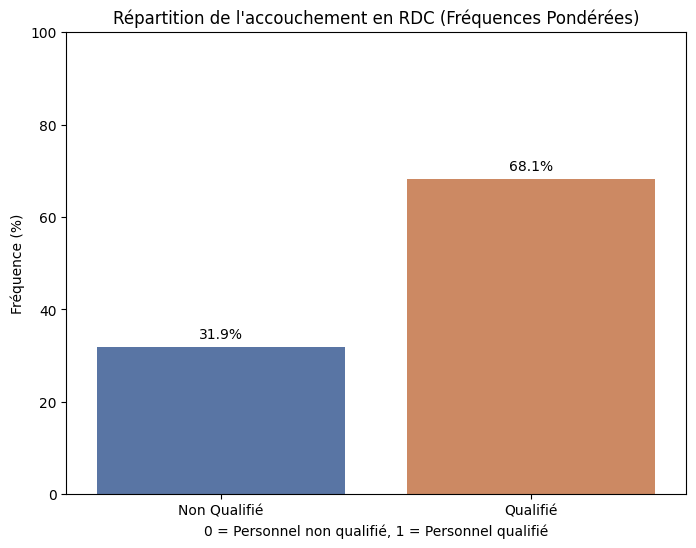

In [27]:
#  Calcul de la somme des poids par catégorie
sba_stats = dataIR_final.groupby('SBA')['poids_final'].sum().reset_index()

#  Conversion de la somme des poids en Fréquence (Pourcentage)
total_poids = sba_stats['poids_final'].sum()
sba_stats['frequence'] = (sba_stats['poids_final'] / total_poids) * 100

# Création du graphique
plt.figure(figsize=(8, 6))
ax = sns.barplot(data=sba_stats, x="SBA", y="frequence", palette="deep")

#  Ajout des étiquettes de pourcentage au-dessus des barres
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

#  Personnalisation des axes
plt.title("Répartition de l'accouchement en RDC (Fréquences Pondérées)")
plt.xlabel("0 = Personnel non qualifié, 1 = Personnel qualifié")
plt.ylabel("Fréquence (%)")
plt.ylim(0, 100) # Pour que l'échelle soit sur 100%
plt.xticks(ticks=[0, 1], labels=["Non Qualifié", "Qualifié"])

plt.show()

###
Analyse univariee des variables explicatives

In [28]:
dataIR_final["V201"].unique()

array([ 4,  1,  8,  9, 13,  7,  5,  6,  2,  3, 10, 11, 12, 15, 14, 16])

In [29]:
# Recodage en parité groupée
def recoder_parite(v201):
    if pd.isna(v201):
        return np.nan
    elif v201 <= 2:
        return 1  # 1-2 enfants
    elif v201 <= 4:
        return 2  # 3-4 enfants
    else:
        return 3  # 5+ enfants

In [30]:
dataIR_final["parite"] = dataIR_final["V201"].apply(recoder_parite)

# Ou plus simple avec pandas cut
dataIR_final["parite"] = pd.cut(dataIR_final["V201"], 
                      bins=[0, 2, 4, 100], 
                      labels=[1, 2, 3],
                      include_lowest=True)

C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_11068\2897615421.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataIR_final["parite"] = dataIR_final["V201"].apply(recoder_parite)
C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_11068\2897615421.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataIR_final["parite"] = pd.cut(dataIR_final["V201"],


In [31]:
# Vérification
print(dataIR_final["parite"].value_counts().sort_index())

parite
1    1746
2    1575
3    1692
Name: count, dtype: int64


In [32]:
dataIR_final["parite"]=dataIR_final["parite"].astype("category")

C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_11068\3750134462.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataIR_final["parite"]=dataIR_final["parite"].astype("category")


In [33]:
dataIR_final=dataIR_final.drop(columns="V201")

In [34]:
dataIR_final.columns

Index(['CASEID', 'V005', 'V021', 'V023', 'V013', 'V024', 'V025', 'V106',
       'V130', 'V190', 'V701', 'SBA', 'ANC', 'Media_exposure',
       'autonomie_decisionnelle', 'attitude_violence', 'poids_final',
       'parite'],
      dtype='object')

###
l'execution du code ci-dessous produira un document word contenant un tableau des resultats de l'analyse univariee

In [35]:
from docx import Document
from docx.shared import Pt

exclure = ['SBA', 'poids_final', 'V005', 'CASEID', 'V021', 'V023', 'nb_decisions']
toutes_les_vars = [col for col in dataIR_final.columns if col not in exclure]


# DICTIONNAIRE DES TITRES DES VARIABLES
labels = {
    'V013': "Groupe d'âge",
    'V024': "Région",
    'V025': "Milieu de résidence",
    'V106': "Niveau d'éducation",
    'V130': "Religion",
    'V190': "Quintile de richesse",
    'parite': "Nombre d'enfants",  
    'V701': "Niveau d'éducation du mari",
    'ANC': "Consultations Prénatales (au moins 1)",
    'Media_exposure': "Exposition aux médias",
    'autonomie_decisionnelle': "Autonomie décisionnelle (Score)",
    'attitude_violence': "Attitude face à la violence conjugale"
}


#  DECODEUR COMPLET 
modalites_labels = {
    'V013': {1: "15-19", 2: "20-24", 3: "25-29", 4: "30-34", 5: "35-39", 6: "40-44", 7: "45-49"},
    'V024': {
        1: "Adamaoua", 2: "Centre (sans Yaoundé)", 3: "Douala", 4: "Est", 
        5: "Extreme-Nord", 6: "Littoral (sans Douala)", 7: "Nord", 8: "Nord-Ouest", 
        9: "Ouest", 10: "Sud", 11: "Sud-Ouest", 12: "Yaoundé"
    },
    'V025': {1: "Urbain", 2: "Rural"},
    'V106': {0: "Aucun niveau", 1: "Primaire", 2: "Secondaire", 3: "Supérieur"},
    'V701': {0: "Aucun niveau", 1: "Primaire", 2: "Secondaire", 3: "Supérieur", 8: "Je ne sais pas"},
    'V190': {1: "Le plus pauvre (Poorest)", 2: "Pauvre (Poorer)", 3: "Moyen (Middle)", 4: "Riche (Richer)", 5: "Le plus riche (Richest)"},
    'V130': {
        1: "Catholique", 2: "Protestant", 3: "Autre chrétien", 4: "Musulman", 
        5: "Animiste/", 7: "Aucun", 
        96: "Autre"
    },
    # TRADUCTION DE VOS MODALITÉS DE PARITÉ :
    # label 1 = 1 a 2 enfants, label 2 = 3 a 4 enfants, label 3 = 5 enfants ou plus
    'parite': {1: "1-2 enfants", 2: "3-4 enfants", 3: "5 enfants ou plus"},
    
    'Media_exposure': {0: "Non exposée", 1: "Exposée (au moins 1 média x/semaine)"},
    'autonomie_decisionnelle': {1: "Basse autonomie (0 décision)", 2: "Moyenne autonomie (1-2 déc.)", 3: "Haute autonomie (3 déc.)"},
    'attitude_violence': {0: "Rejette la violence (5 Non)", 1: "Justifie la violence (au moins 1 Oui)"},
    'ANC': {0: "Aucune visite", 1: "Au moins 1 visite"}
}


#  CRÉATION ET REMPLISSAGE DU TABLEAU WORD

doc = Document()
doc.add_heading("Tableau 1 : Caractéristiques socio-démographiques de l'échantillon (Cameroun)", level=1)

table = doc.add_table(rows=1, cols=3)
table.style = 'Table Grid'

hdr_cells = table.rows[0].cells
hdr_cells[0].text = 'Variable / Catégorie'
hdr_cells[1].text = 'Effectif brut (n)'
hdr_cells[2].text = 'Pourcentage pondéré (%)'

total_poids = dataIR_final['poids_final'].sum()

for var in toutes_les_vars:
    libelle = labels.get(var, var)
    
    # Ligne d'en-tête de la variable en gras
    row_cells = table.add_row().cells
    row_cells[0].text = libelle
    row_cells[0].paragraphs[0].runs[0].bold = True
    row_cells[1].text = ""
    row_cells[2].text = ""
    
    # Statistiques descriptives
    n_brut = dataIR_final[var].value_counts()
    poids_cat = dataIR_final.groupby(var, observed=False)['poids_final'].sum()
    
    # Tri des modalités (1, 2, 3...) pour un affichage séquentiel parfait
    categories_triees = sorted(n_brut.index)
    
    for cat in categories_triees:
        pct = (poids_cat[cat] / total_poids) * 100
        cat_nom = modalites_labels.get(var, {}).get(cat, cat)
            
        row_cells = table.add_row().cells
        row_cells[0].text = f"   {cat_nom}"  # Alignement / Indentation style Sanni Yaya
        row_cells[1].text = str(int(n_brut[cat]))
        row_cells[2].text = f"{pct:.1f}%"

# Sauvegarde finale
file_name = "Tableau1_Cameroun_Avec_Parite.docx"
doc.save(file_name)
print(f"Le fichier Word final '{file_name}' a été généré avec votre recodage de la parité !")

Le fichier Word final 'Tableau1_Cameroun_Avec_Parite.docx' a été généré avec votre recodage de la parité !


###
graphique de quelques variables

C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_11068\3248848674.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_11068\3248848674.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels_affichage, rotation=45, ha="right")


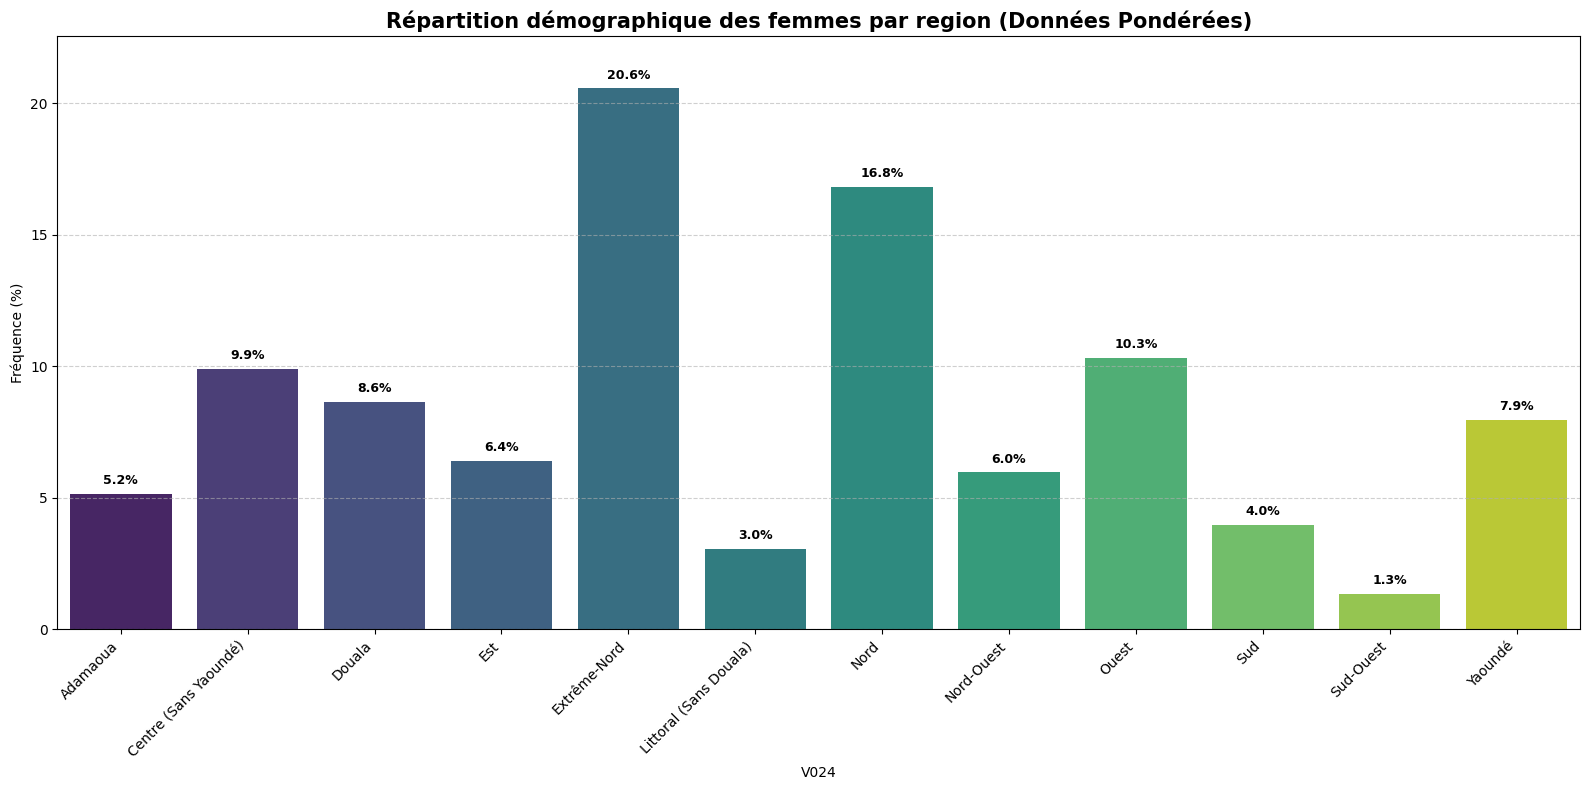

In [36]:
# # repartition des regions 

dataIR_final['V024'] = dataIR_final['V024'].astype(int) # On s'assure d'avoir des entiers pour mapper

# CALCUL PONDÉRÉ
prov_weighted = dataIR_final.groupby('V024')['poids_final'].sum().reset_index()
total_poids = prov_weighted['poids_final'].sum()
prov_weighted['pourcentage'] = (prov_weighted['poids_final'] / total_poids) * 100

# L'ÉTAPE CRUCIALE : On traduit les codes numériques (1 à 12) en noms de provinces
dictionnaire_regions = {
    1: "Adamaoua", 2: "Centre (sans Yaoundé)", 3: "Douala", 4: "Est", 
    5: "Extrême-Nord", 6: "Littoral (sans Douala)", 7: "Nord", 8: "Nord-Ouest", 
    9: "Ouest", 10: "Sud", 11: "Sud-Ouest", 12: "Yaoundé"
}
prov_weighted['V024'] = prov_weighted['V024'].map(dictionnaire_regions)

# VOTRE LISTE DE RÉFÉRENCE 
provinces_ordre = [
    "Adamaoua", "Centre (sans Yaoundé)", "Douala", "Est", "Extrême-Nord", 
    "Littoral (sans Douala)", "Nord", "Nord-Ouest", "Ouest", "Sud", "Sud-Ouest", "Yaoundé"
]

# CRÉATION DU GRAPHIQUE
plt.figure(figsize=(16, 8))

ax = sns.barplot(
    data=prov_weighted, 
    x="V024", 
    y="pourcentage", 
    palette="viridis",
    order=provinces_ordre  # Maintenant les noms correspondent parfaitement !
)

# ESTHÉTIQUE DES LABELS
labels_affichage = [p.title() for p in provinces_ordre]
ax.set_xticklabels(labels_affichage, rotation=45, ha="right")

# ANNOTATIONS (Pourcentages au-dessus des barres)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=9, fontweight='bold')

plt.title("Répartition démographique des femmes par region (Données Pondérées)", fontsize=15, fontweight='bold')
plt.ylabel("Fréquence (%)")
plt.ylim(0, prov_weighted['pourcentage'].max() + 2)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

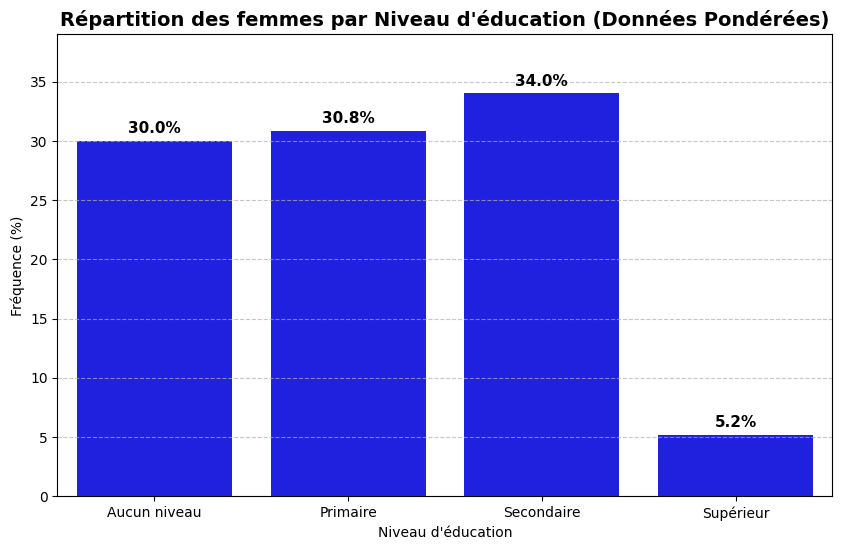

In [37]:
#  repartitions des femmes par niveau d'educaton
# PRÉPARATION DES DONNÉES PONDÉRÉES

# On convertion en entier 
dataIR_final['V106'] = dataIR_final['V106'].astype(int)

educ_weighted = dataIR_final.groupby('V106')['poids_final'].sum().reset_index()

# CALCUL DES POURCENTAGES RÉELS (Méthode Sanni Yaya)
total_poids = educ_weighted['poids_final'].sum()
educ_weighted['pourcentage'] = (educ_weighted['poids_final'] / total_poids) * 100

# TRADUCTION DES CODES EN CLAIR
dictionnaire_education = {
    0: "Aucun niveau",
    1: "Primaire",
    2: "Secondaire",
    3: "Supérieur"
}
educ_weighted['V106'] = educ_weighted['V106'].map(dictionnaire_education)

# ORDRE D'AFFICHAGE LOGIQUE (Du moins instruit au plus instruit)
ordre_education = ["Aucun niveau", "Primaire", "Secondaire", "Supérieur"]

# CRÉATION DU GRAPHIQUE
plt.figure(figsize=(10, 6))

# On force l'ordre d'affichage pour correspondre parfaitement au tableau Word
ax = sns.barplot(
    data=educ_weighted, 
    x="V106", 
    y="pourcentage", 
    color="blue",
    order=ordre_education
)

# CONFIGURATION DES AXES
plt.title("Répartition des femmes par Niveau d'éducation (Données Pondérées)", fontsize=14, fontweight='bold')
plt.xlabel("Niveau d'éducation")
plt.ylabel("Fréquence (%)")

# AJOUT DES ÉTIQUETTES (Labels) EXACTES DU TABLEAU
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=11, fontweight='bold')

# Ajustement de l'axe Y pour laisser de la place au texte
plt.ylim(0, educ_weighted['pourcentage'].max() + 5)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

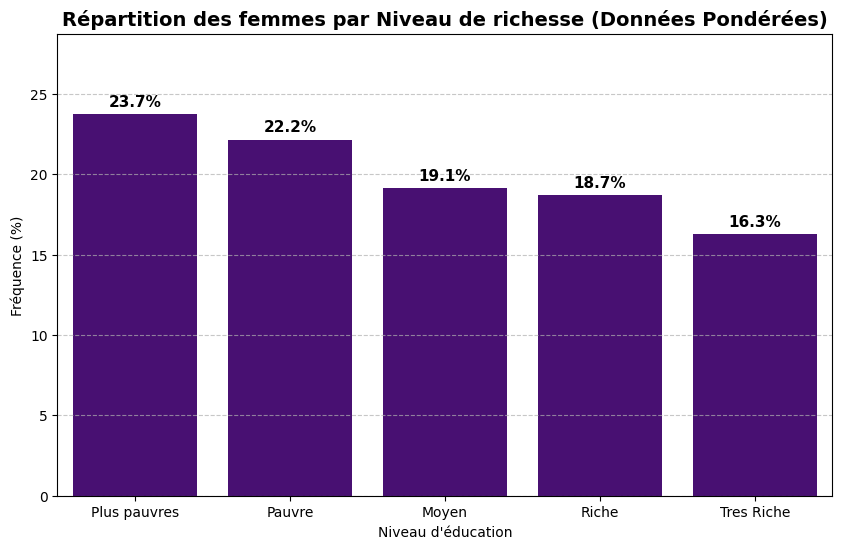

In [38]:
#  repartitions des femmes par niveau de richesse
# PRÉPARATION DES DONNÉES PONDÉRÉES

# On convertion en entier 
dataIR_final['V190'] = dataIR_final['V190'].astype(int)

educ_weighted = dataIR_final.groupby('V190')['poids_final'].sum().reset_index()

# CALCUL DES POURCENTAGES RÉELS (Méthode Sanni Yaya)
total_poids = educ_weighted['poids_final'].sum()
educ_weighted['pourcentage'] = (educ_weighted['poids_final'] / total_poids) * 100

# TRADUCTION DES CODES EN CLAIR
dictionnaire_richesse = {
    1: "Plus pauvres",
    2: "Pauvre",
    3: "Moyen",
    4: "Riche",
    5: "Tres Riche"
}
educ_weighted['V106'] = educ_weighted['V190'].map(dictionnaire_richesse)

# ORDRE D'AFFICHAGE LOGIQUE (Du moins instruit au plus instruit)
ordre_richesse = ["Plus pauvres", "Pauvre", "Moyen", "Riche","Tres Riche"]

# CRÉATION DU GRAPHIQUE
plt.figure(figsize=(10, 6))

# On force l'ordre d'affichage pour correspondre parfaitement au tableau Word
ax = sns.barplot(
    data=educ_weighted, 
    x="V106", 
    y="pourcentage", 
    color="indigo",
    order=ordre_richesse
)

# CONFIGURATION DES AXES
plt.title("Répartition des femmes par Niveau de richesse (Données Pondérées)", fontsize=14, fontweight='bold')
plt.xlabel("Niveau d'éducation")
plt.ylabel("Fréquence (%)")

# AJOUT DES ÉTIQUETTES (Labels) EXACTES DU TABLEAU
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=11, fontweight='bold')

# Ajustement de l'axe Y pour laisser de la place au texte
plt.ylim(0, educ_weighted['pourcentage'].max() + 5)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

## Analyse Bivariee

#
NB: l'execution de cette cellule creere un document word contenant le tableau de statistique  de la relation entre la variable dependante et chaque variable explicatives

In [39]:
from scipy.stats import chi2_contingency
from docx import Document
from docx.shared import Pt


# SÉLECTION DES VARIABLES NETTOYÉES (AVEC EXCLUSION DES PARASITES)

# On ajoute 'V190_str', 'V201' et 'V208' pour éliminer les doublons et résidus de calculs
exclure = [
    'SBA', 'poids_final', 'V005', 'CASEID', 'V021', 'V023', 
    'nb_decisions']
variables_indep = [col for col in dataIR_final.columns if col not in exclure]

#  DICTIONNAIRE DES TITRES DES VARIABLES

labels = {
    'V013': "Groupe d'âge",
    'V024': "Région",
    'V025': "Milieu de résidence",
    'V106': "Niveau d'éducation",
    'V130': "Religion",
    'V190': "Quintile de richesse",
    'parite': "Parité (Nombre d'enfants)",
    'V701': "Niveau d'éducation du mari",
    'ANC': "Consultations Prénatales (au moins 1)",
    'Media_exposure': "Exposition aux médias",
    'autonomie_decisionnelle': "Autonomie décisionnelle (Score)",
    'attitude_violence': "Attitude face à la violence conjugale"
}


#  DÉCODEUR COMPLEMENTS DES MODALITÉS

modalites_labels = {
    'V013': {1: "15-19", 2: "20-24", 3: "25-29", 4: "30-34", 5: "35-39", 6: "40-44", 7: "45-49"},
    'V024': {
        1: "Adamaoua", 2: "Centre (sans Yaoundé)", 3: "Douala", 4: "Est", 
        5: "Extrême-Nord", 6: "Littoral (sans Douala)", 7: "Nord", 8: "Nord-Ouest", 
        9: "Ouest", 10: "Sud", 11: "Sud-Ouest", 12: "Yaoundé"
    },
    'V025': {1: "Urbain", 2: "Rural"},
    'V106': {0: "Aucun niveau", 1: "Primaire", 2: "Secondaire", 3: "Supérieur"},
    'V701': {0: "Aucun niveau", 1: "Primaire", 2: "Secondaire", 3: "Supérieur", 8: "Je ne sais pas"},
    'V190': {1: "Le plus pauvre (Poorest)", 2: "Pauvre (Poorer)", 3: "Moyen (Middle)", 4: "Riche (Richer)", 5: "Le plus riche (Richest)"},
    'V130': {
        1: "Catholique", 2: "Protestant", 3: "Autre chrétien", 4: "Musulman", 
        5: "Animiste", 7: "Aucun", 
        96: "Autre"
    },
    'parite': {1: "1-2 enfants", 2: "3-4 enfants", 3: "5 enfants ou plus"},
    'Media_exposure': {0: "Non exposée", 1: "Exposée (au moins 1 média x/semaine)"},
    'autonomie_decisionnelle': {1: "Basse autonomie (0 décision)", 2: "Moyenne autonomie (1-2 déc.)", 3: "Haute autonomie (3 déc.)"},
    'attitude_violence': {0: "Rejette la violence (5 Non)", 1: "Justifie la violence (au moins 1 Oui)"},
    'ANC': {0: "Aucune visite", 1: "Au moins 1 visite"}
}


# CRÉATION DU DOCUMENT WORD

doc = Document()
doc.add_heading("Tableau 2 : Caractéristiques des participantes et recours à l'accouchement qualifié (Pondéré)", level=1)

table = doc.add_table(rows=1, cols=5)
table.style = 'Table Grid'

hdr_cells = table.rows[0].cells
hdr_cells[0].text = 'Variable / Catégorie'
hdr_cells[1].text = 'Non Qualifié % (n)'
hdr_cells[2].text = 'Qualifié % (n)'
hdr_cells[3].text = 'Total (n)'
hdr_cells[4].text = 'p-value'

for var in variables_indep:
    libelle_variable = labels.get(var, var)
    
    # CALCULS PONDÉRÉS
    ct_weighted = pd.crosstab(
        index=dataIR_final[var], 
        columns=dataIR_final['SBA'], 
        values=dataIR_final['poids_final'], 
        aggfunc='sum'
    ).fillna(0)
    
    perc_weighted = ct_weighted.div(ct_weighted.sum(axis=1), axis=0) * 100
    
    # TEST DU CHI-DEUX
    contingency = pd.crosstab(dataIR_final[var], dataIR_final['SBA'])
    chi2, p, dof, ex = chi2_contingency(contingency)
    
    # AJOUT DE LA LIGNE DE TITRE
    row_cells = table.add_row().cells
    row_cells[0].text = libelle_variable
    row_cells[0].paragraphs[0].runs[0].bold = True
    
    p_text = "< 0.001" if p < 0.001 else f"{p:.3f}"
    row_cells[4].text = p_text
    
    categories_triees = sorted(ct_weighted.index)
    
    for cat in categories_triees:
        cat_cells = table.add_row().cells
        
        cat_nom = modalites_labels.get(var, {}).get(cat, cat)
        cat_cells[0].text = f"   {cat_nom}"
        
        n_0 = ct_weighted.loc[cat, 0] if 0 in ct_weighted.columns else 0
        p_0 = perc_weighted.loc[cat, 0] if 0 in perc_weighted.columns else 0
        cat_cells[1].text = f"{p_0:.1f}% ({int(n_0)})"
        
        n_1 = ct_weighted.loc[cat, 1] if 1 in ct_weighted.columns else 0
        p_1 = perc_weighted.loc[cat, 1] if 1 in perc_weighted.columns else 0
        cat_cells[2].text = f"{p_1:.1f}% ({int(n_1)})"
        
        total_n = n_0 + n_1
        cat_cells[3].text = f"{int(total_n)}"

# SAUVEGARDE FINALE
file_name = "Tableau2_Bivarie_Cameroun.docx"
doc.save(file_name)
print(f"Le Tableau 2 bivarié parfaitement nettoyé a été enregistré sous '{file_name}' !")

Le Tableau 2 bivarié parfaitement nettoyé a été enregistré sous 'Tableau2_Bivarie_Cameroun.docx' !


In [40]:
dataIR_final.columns

Index(['CASEID', 'V005', 'V021', 'V023', 'V013', 'V024', 'V025', 'V106',
       'V130', 'V190', 'V701', 'SBA', 'ANC', 'Media_exposure',
       'autonomie_decisionnelle', 'attitude_violence', 'poids_final',
       'parite'],
      dtype='object')

In [41]:
dataIR_final.columns

Index(['CASEID', 'V005', 'V021', 'V023', 'V013', 'V024', 'V025', 'V106',
       'V130', 'V190', 'V701', 'SBA', 'ANC', 'Media_exposure',
       'autonomie_decisionnelle', 'attitude_violence', 'poids_final',
       'parite'],
      dtype='object')

###
quelques graphiques 

C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_11068\638620801.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_weighted = dataIR_final.groupby(['V025', 'SBA'])['poids_final'].sum().reset_index()
C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_11068\638620801.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_weighted['pourcentage'] = df_weighted.groupby('V025')['poids_final'].transform(lambda x: (x / x.sum()) * 100)
C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_11068\638620801.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or usi

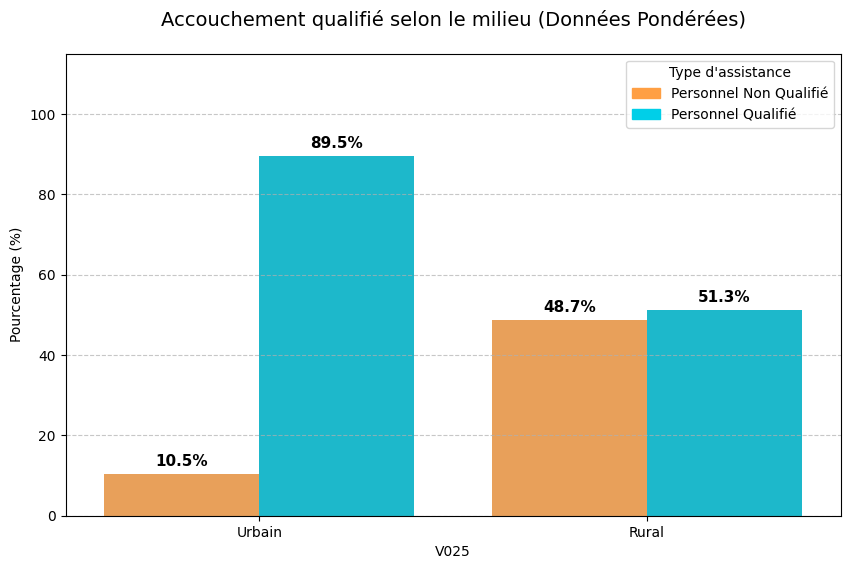

In [42]:
# repartition des SBA par milieu de residence
import matplotlib.patches as mpatches

# CALCUL PONDÉRÉ : On fait la somme des poids au lieu de compter les lignes
# On groupe par milieu (v025) et par SBA
df_weighted = dataIR_final.groupby(['V025', 'SBA'])['poids_final'].sum().reset_index()

# CALCUL DES POURCENTAGES : On divise la somme des poids de chaque groupe 
# par la somme totale des poids du milieu de résidence
df_weighted['pourcentage'] = df_weighted.groupby('V025')['poids_final'].transform(lambda x: (x / x.sum()) * 100)

# CONFIGURATION DU GRAPHIQUE
couleurs = {0: "#FF9F43", 1: "#00CFE8"} # Orange=Non Qualifié, Bleu=Qualifié

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_weighted, 
    x="V025", 
    y="pourcentage", 
    hue="SBA", 
    palette=couleurs
)

# Correction des labels (1=Urbain, 2=Rural selon l'EDS)
ax.set_xticklabels(["Urbain", "Rural"])

# Légende
orange_patch = mpatches.Patch(color='#FF9F43', label='Personnel Non Qualifié')
blue_patch = mpatches.Patch(color='#00CFE8', label='Personnel Qualifié')
plt.legend(handles=[orange_patch, blue_patch], title="Type d'assistance", loc='upper right')

# Ajout des étiquettes
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points',
                    fontsize=11, fontweight='bold')

plt.title("Accouchement qualifié selon le milieu (Données Pondérées)", fontsize=14, pad=20)
plt.ylabel("Pourcentage (%)")
plt.ylim(0, 115)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\Ted Harris\AppData\Local\Temp\ipykernel_11068\3715263563.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_richesse = dataIR_final.groupby(['V190', 'SBA'])['poids_final'].sum().reset_index()


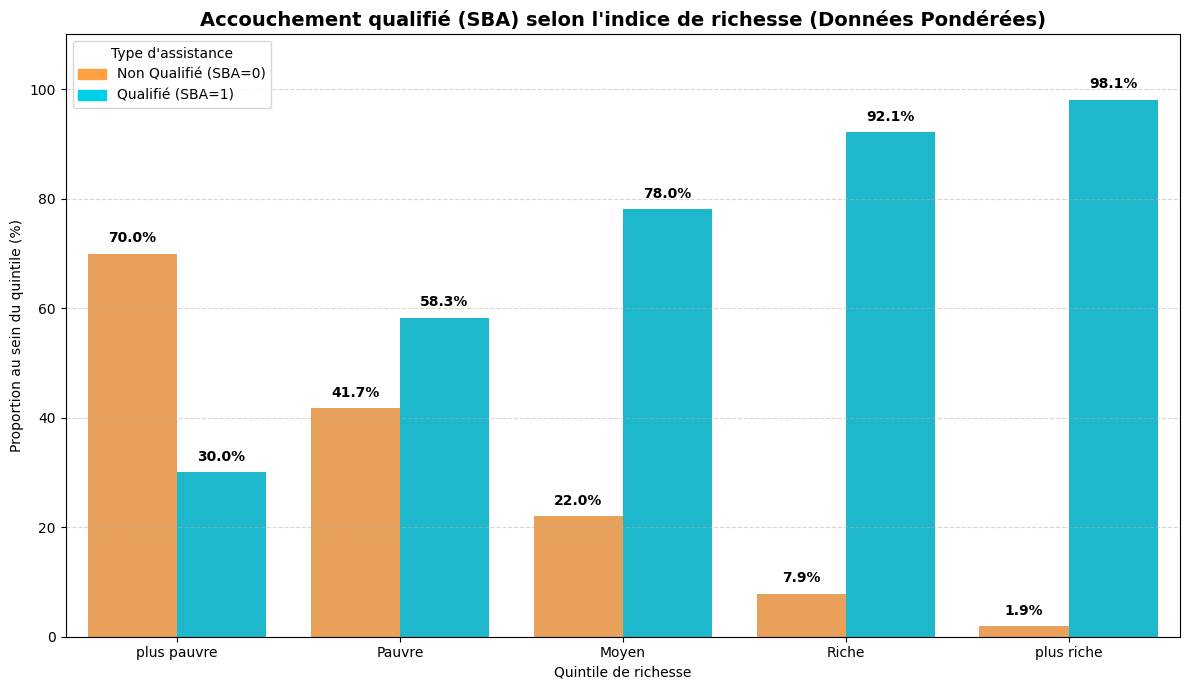

In [43]:
# repartition des femmes par indices de richesses
import matplotlib.patches as mpatches

# NETTOYAGE ET CALCUL PONDÉRÉ


#  On s'assure que V190 est un entier propre
dataIR_final['V190'] = dataIR_final['V190'].astype(int)

# 2. Calcul de la somme des poids par Quintile et SBA
df_richesse = dataIR_final.groupby(['V190', 'SBA'])['poids_final'].sum().reset_index()

# 3. Calcul des pourcentages intra-quintile (somme de SBA 0 + SBA 1 = 100% pour chaque niveau)
df_richesse['pourcentage'] = df_richesse.groupby('V190')['poids_final'].transform(lambda x: (x / x.sum()) * 100)

# 4. TRADUCTION DES CODES NUMÉRIQUES EN FRANÇAIS
dictionnaire_richesse = {
    1: "plus pauvre",
    2: "Pauvre",
    3: "Moyen",
    4: "Riche",
    5: "plus riche"
}
df_richesse['V190_nom'] = df_richesse['V190'].map(dictionnaire_richesse)

# 5. ORDRE STRICT DES BARRES (Du plus démuni au plus aisé)
ordre_richesse = ["plus pauvre", "Pauvre", "Moyen", "Riche", "plus riche"]


# CRÉATION DU GRAPHIQUE

plt.figure(figsize=(12, 7))

# Couleurs distinctives (Orange pour Non Qualifié, Cyan pour Qualifié)
couleurs = {0: "#FF9F43", 1: "#00CFE8"}

ax = sns.barplot(
    data=df_richesse, 
    x="V190_nom", 
    y="pourcentage", 
    hue="SBA", 
    palette=couleurs,
    order=ordre_richesse
)

# ÉTIQUETTES ET ESTHÉTIQUE
plt.title("Accouchement qualifié (SBA) selon l'indice de richesse (Données Pondérées)", fontsize=14, fontweight='bold')
plt.xlabel("Quintile de richesse")
plt.ylabel("Proportion au sein du quintile (%)")

# Légende personnalisée et propre
orange_patch = mpatches.Patch(color='#FF9F43', label='Non Qualifié (SBA=0)')
cyan_patch = mpatches.Patch(color='#00CFE8', label='Qualifié (SBA=1)')
plt.legend(handles=[orange_patch, cyan_patch], title="Type d'assistance", loc='upper left')

# AJOUT DES POURCENTAGES AU-DESSUS DES BARRES
for p in ax.patches:
    h = p.get_height()
    if h > 0:
        ax.annotate(f'{h:.1f}%', 
                    (p.get_x() + p.get_width() / 2., h), 
                    ha='center', va='bottom', 
                    xytext=(0, 6), textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.ylim(0, 110)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [44]:
# Exportation finale
dataIR_final.to_csv('PrCMIR71FL.csv', index=False, sep=';')
dataIR_final.to_excel('PrCMIR71FL.xlsx', index=False)

## FIN DE L'ANALYSE